In [29]:
import numpy 
import matplotlib.pyplot as plt  
import os 
import pandas as pd 
import numpy as np  


from sklearn.model_selection import train_test_split

np.random.seed(123)  # For reproducibility

### Data preparation 

In [31]:
# Load the insurance data , should be in the same directory as this script
insurance_data = pd.read_csv('insurance_data_raw.csv')

# Separate features and target variable
target = insurance_data["claim"].values


insurance_data.head(n=9)


,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7
5,42.0,female,89,37.9,NoDisease,0,0,AtlanticCity,78,0,0,Dancer,6474.0
6,18.0,male,59,23.8,NoDisease,0,0,Portland,64,0,0,Singer,1705.6
7,21.0,male,52,26.8,NoDisease,0,0,Cambridge,74,1,0,Actor,1534.3
8,63.0,male,55,NaN,NoDisease,0,0,Hartford,70,1,0,Dancer,13390.6


In [21]:
insurance_data[insurance_data.isna().any(axis=1)]


,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
8,63.0,male,55,NaN,NoDisease,0,0,Hartford,70,1,0,Dancer,13390.6
56,46.0,female,68,NaN,NoDisease,2,0,FallsCity,60,1,0,Dancer,8825.1
60,41.0,male,82,NaN,NoDisease,2,0,Canton,62,1,0,Politician,7256.7
63,45.0,male,60,NaN,NoDisease,2,0,Minneapolis,86,1,0,Actor,8413.5
74,18.0,female,44,NaN,NoDisease,0,0,Oceanside,96,1,0,Photographer,21344.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14959,54.0,male,81,NaN,NoDisease,1,1,Newport,76,1,0,Singer,41999.5
14962,NaN,male,47,29.0,NoDisease,1,0,Atlanta,86,1,0,Academician,4040.6
14969,NaN,male,47,29.0,NoDisease,1,0,NewOrleans,86,1,0,Academician,4040.6
14977,45.0,female,84,NaN,NoDisease,1,1,Cambridge,0,1,1,ITProfessional,39725.5


In [14]:
from sklearn.preprocessing import LabelEncoder

# Remove 'claim' column
insurance_data_no_claim = insurance_data.drop(columns=['claim'])

insurance_data_no_claim = insurance_data
# Encode string columns to integer
string_columns = insurance_data_no_claim.select_dtypes(include='object').columns
label_encoders = {}

for col in string_columns:
    le = LabelEncoder()
    insurance_data_no_claim[col] = le.fit_transform(insurance_data_no_claim[col])
    label_encoders[col] = le

insurance_data_no_claim.head()

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,1.459227,1,64,-0.974434,8,1,0,55,0.172509,0,0,2,0.205613
1,0.674408,0,75,-1.252078,8,1,0,5,0.481492,1,1,16,0.150023
2,-0.538495,0,64,-2.036014,4,2,1,63,0.996465,1,1,0,0.513310
3,1.530574,0,53,1.001737,8,1,1,64,0.172509,1,0,10,0.760808
4,-1.466008,0,50,-1.578718,8,0,0,8,0.687481,1,0,22,0.027144


In [28]:
insurance_data.shape

(15000, 13)

In [25]:
# How to handle missing values ####
insurance_data_no_claim.isna().sum() 
#get the number of missing values in each column
#insurance_data_no_claim = insurance_data_no_claim.dropna()  # Drop rows with missing values
#insurance_data_no_claim = insurance_data_no_claim.fillna(insurance_data_no_claim.mean())  # Fill missing values with column mean



# Receive a summary of the dataframe ####
# insurance_data_no_claim.info() get a summary of the dataframe
# insurance_data_no_claim.describe() get a statistical summary of the dataframe

print(insurance_data_no_claim.isna().sum())
print(insurance_data.isna().sum())

age                    396
sex                      0
weight                   0
bmi                    956
hereditary_diseases      0
no_of_dependents         0
smoker                   0
city                     0
bloodpressure            0
diabetes                 0
regular_ex               0
job_title                0
claim                    0
dtype: int64
age                    396
sex                      0
weight                   0
bmi                    956
hereditary_diseases      0
no_of_dependents         0
smoker                   0
city                     0
bloodpressure            0
diabetes                 0
regular_ex               0
job_title                0
claim                    0
dtype: int64


### Feature engineering  

In [ ]:
# Discard not significant features
features = insurance_data_no_claim.drop(columns=['index', 'PatientID'])


# Standardize numerical features
features["age"] = (features["age"] - features["age"].mean()) / features["age"].std()
features["bloodpressure"] = (features["bloodpressure"] - features["bloodpressure"].mean()) / features["bloodpressure"].std()
features["bmi"] = (features["bmi"] - features["bmi"].mean()) / features["bmi"].std()


# Normalize to [0,1]
max_target = target.max()

target = target / max_target    
target_ind = target.copy()


# Split the dataset into training, validation, and test sets ####
from sklearn.model_selection import train_test_split

# Split the data into train, validation, and test sets (e.g., 60% train, 20% val, 20% test)

# First split into train and temp (train: 60%, temp: 40%)
X_temp, X_test, y_temp, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

print("Train set size:", X_train.shape)
print("Validation set size:", X_val.shape)
print("Test set size:", X_test.shape)

Train set size: (798, 9)
Validation set size: (267, 9)
Test set size: (267, 9)


In [11]:
features.to_csv("insurance_data_mod.csv")

Explained variance ratio per component: [0.1911 0.1649 0.1459 0.1241 0.1238 0.1054 0.0789 0.0659]
Cumulative explained variance: [0.1911 0.356  0.5019 0.626  0.7498 0.8552 0.9341 1.    ]


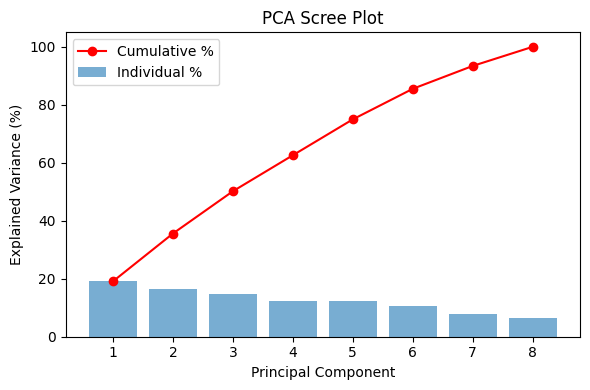

Top loadings (absolute) for PC1 and PC2:
                    PC1       PC2
bloodpressure  0.536907  0.460148
smoker         0.524617  0.423294
gender         0.442057  0.541638
age            0.439914  0.542857
bmi            0.211701  0.036734
region         0.051113  0.055998
children       0.011820  0.128553
diabetic       0.000591  0.003249
                    PC1       PC2
age            0.439914  0.542857
gender         0.442057  0.541638
bloodpressure  0.536907  0.460148
smoker         0.524617  0.423294
children       0.011820  0.128553
region         0.051113  0.055998
bmi            0.211701  0.036734
diabetic       0.000591  0.003249


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Prepare data
X_train = features.copy()  # use existing processed DataFrame
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Full PCA to inspect explained variance
pca_full = PCA()
pca_full.fit(X_scaled)
explained = pca_full.explained_variance_ratio_
cumulative = explained.cumsum()

print("Explained variance ratio per component:", np.round(explained, 4))
print("Cumulative explained variance:", np.round(cumulative, 4))

# Scree plot
plt.figure(figsize=(6,4))
plt.bar(range(1, len(explained)+1), explained * 100, alpha=0.6, label='Individual %')
plt.plot(range(1, len(cumulative)+1), cumulative * 100, marker='o', color='red', label='Cumulative %')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('PCA Scree Plot')
plt.xticks(range(1, len(explained)+1))
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
# PCA to 2 components for visualization
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

# Scatter plot of first 2 principal components, colored by the selected column (e.g. region)
col_values = X_train[col].values  # 'col' variable exists in the notebook and equals 'region'
unique_vals = np.unique(col_values)


# Optionally display loadings for first two components
loadings = pd.DataFrame(pca2.components_.T, index=X_train.columns, columns=['PC1', 'PC2'])
print("Top loadings (absolute) for PC1 and PC2:")
print(loadings.abs().sort_values('PC1', ascending=False).head(8))
print(loadings.abs().sort_values('PC2', ascending=False).head(8))

Top loadings (absolute) for PC1 and PC2:
                    PC1       PC2
bloodpressure  0.536907  0.460148
smoker         0.524617  0.423294
gender         0.442057  0.541638
age            0.439914  0.542857
bmi            0.211701  0.036734
region         0.051113  0.055998
children       0.011820  0.128553
diabetic       0.000591  0.003249
                    PC1       PC2
age            0.439914  0.542857
gender         0.442057  0.541638
bloodpressure  0.536907  0.460148
smoker         0.524617  0.423294
children       0.011820  0.128553
region         0.051113  0.055998
bmi            0.211701  0.036734
diabetic       0.000591  0.003249


### ML (using sklearn and pytorch)

#### Linear Regression (sklearn)

In [21]:
from sklearn.linear_model import LinearRegression

# Features (insurance_data_no_claim) und Zielvariable (target) verwenden
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Vorhersage für die Trainingsdaten
predictions = lin_reg.predict(X_test)

# Beispiel: Ausgabe der ersten 5 Vorhersagen
print(predictions[:5])
print(y_test[:5] )

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)
print("Mean Squared Error 10^3:", mse *10**3)


from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Train Linear Regression on training set
lin_reg_val = LinearRegression()
lin_reg_val.fit(X_train, y_train)

# Predict on validation set
val_predictions = lin_reg_val.predict(X_val)

# Output first 5 predictions and ground truth
print("Validation predictions:", val_predictions[:5])
print("Validation ground truth:", y_val[:5])

# Calculate MSE for validation set
mse_val = mean_squared_error(y_val, val_predictions)
print("Validation Mean Squared Error 10^3:", mse_val * 10**3)

[0.53136909 0.34648276 0.62292066 0.14166498 0.10454788]
[0.67828334 0.31624908 0.62468639 0.06954775 0.05738318]
Mean Squared Error 10^3: 9.782482074235107
Validation predictions: [0.14603854 0.11193906 0.1500007  0.17517987 0.55649881]
Validation ground truth: [0.08528639 0.22515702 0.0788966  0.08464142 0.62523806]
Validation Mean Squared Error 10^3: 11.404751154773935


#### Neural Network (pytorch)

In [22]:
import torch

import torch.nn as nn
import torch.optim as optim
from neural_network import InsuranceRegressor

# Konvertiere die Trainings- und Testdaten in Torch-Tensoren
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


model = InsuranceRegressor(X_train.shape[1])

# Loss und Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training
epochs = 2000
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

# Vorhersage und Auswertung
model.eval()
with torch.no_grad():
    predictions_torch = model(X_test_tensor).squeeze().numpy()
    mse_torch = ((predictions_torch - y_test)**2).mean()
    print("PyTorch MSE 10^3:", mse_torch * 10**3)

Epoch 0, Loss: 0.082211
Epoch 100, Loss: 0.020012
Epoch 200, Loss: 0.008400
Epoch 300, Loss: 0.007494
Epoch 400, Loss: 0.007054
Epoch 500, Loss: 0.006814
Epoch 600, Loss: 0.006635
Epoch 700, Loss: 0.006477
Epoch 800, Loss: 0.006314
Epoch 900, Loss: 0.006200
Epoch 1000, Loss: 0.006104
Epoch 1100, Loss: 0.006003
Epoch 1200, Loss: 0.005930
Epoch 1300, Loss: 0.005868
Epoch 1400, Loss: 0.005826
Epoch 1500, Loss: 0.005790
Epoch 1600, Loss: 0.005745
Epoch 1700, Loss: 0.005672
Epoch 1800, Loss: 0.005598
Epoch 1900, Loss: 0.005502
PyTorch MSE 10^3: 10.60112305181259


In [23]:
# Early Stopping Parameter
patience = 40
best_loss = float('inf')

import torch.nn as nn
import torch.optim as optim




model_es = InsuranceRegressor(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model_es.parameters(), lr=0.001)

# Training mit Early Stopping
epochs = 2000                   

for epoch in range(epochs):
    model_es.train()
    optimizer.zero_grad()
    outputs = model_es(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    # Validierung
    model_es.eval()
    with torch.no_grad():
        val_outputs = model_es(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor)
    
    # Early Stopping Check
    if val_loss.item() < best_loss:
        best_loss = val_loss.item()
        best_model_state = model_es.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Training Loss: {loss.item():.6f}, Validation Loss: {val_loss.item():.6f}")


# Vorhersage und Auswertung
model.eval()
with torch.no_grad():
    predictions_torch = model(X_test_tensor).squeeze().numpy()
    mse_torch = ((predictions_torch - y_test)**2).mean()
    print("PyTorch MSE 10^3:", mse_torch * 10**3)

Epoch 0, Training Loss: 0.067706, Validation Loss: 0.062538
Epoch 100, Training Loss: 0.014955, Validation Loss: 0.015370
Epoch 200, Training Loss: 0.008891, Validation Loss: 0.007906
Epoch 300, Training Loss: 0.007452, Validation Loss: 0.007203
Early stopping at epoch 354
PyTorch MSE 10^3: 10.60112305181259


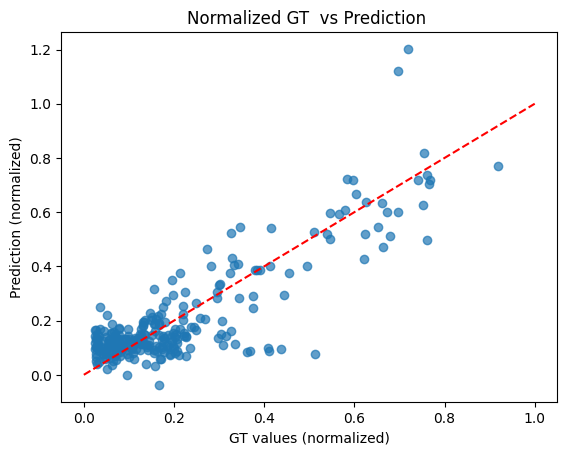

In [24]:
import numpy as np
ideal = np.linspace(0,1, 10 )
plt.scatter(y_test, predictions_torch, alpha= .7)
plt.plot(ideal, ideal, color= "red", linestyle= "--")
plt.title('Normalized GT  vs Prediction ')
plt.xlabel('GT values (normalized)')
plt.ylabel('Prediction (normalized)')
plt.show()

In [25]:
# import seaborn as sns

# # Kombiniere die Features und das Target in einem DataFrame
# pairplot_df = features.copy()
# pairplot_df['target'] = target

# # Erstelle den Pairplot
# sns.pairplot(pairplot_df, hue='target', diag_kind='kde', palette='viridis')